# Laboratorio 2 · Búsqueda informada

**Inteligencia Artificial I**

Este cuaderno tiene las mismas dos partes que el enunciado:

| | |
|---|---|
| **Parte I** | El mapa de 8 ciudades del enunciado, ya metido aquí. Ejecutadla entera sin tocar nada: tienen que salir los mismos números que habéis leído. Sirve para comprobar que entendéis el motor antes de usarlo. |
| **Parte II** | Vuestro mapa. Aquí es donde trabajáis. |

**Ejecutad las celdas en orden, de arriba abajo.** Si algo falla, casi siempre es que os habéis saltado una.

---

## Antes que nada: el motor

Una sola celda con todo lo que hace falta. No hay que tocar nada aquí, pero sí conviene leerla: es el A\* del que habla el enunciado, y las dos líneas del apartado 8 están señaladas con una flecha.

In [7]:
# ═══════════════════════════════════════════════════════════════════
#  MOTOR — ejecutad y seguid. No hay que modificar nada de esta celda.
# ═══════════════════════════════════════════════════════════════════
import csv, heapq, math
from collections import deque


def cargar(ruta):
    """Lee el CSV. Devuelve G[a][b]=minutos, KM[a][b]=kilómetros, VIA[a][b]=tipo."""
    G, KM, VIA = {}, {}, {}
    with open(ruta, encoding='utf-8') as f:
        for r in csv.DictReader(f):
            a, b = r['origen'], r['destino']
            G.setdefault(a, {})[b] = int(r['minutos'])
            G.setdefault(b, {})[a] = int(r['minutos'])
            KM.setdefault(a, {})[b] = int(r['km'])
            KM.setdefault(b, {})[a] = int(r['km'])
            VIA.setdefault(a, {})[b] = r['tipo_via']
            VIA.setdefault(b, {})[a] = r['tipo_via']
    return G, KM, VIA


def dijkstra(G, origen):
    """Coste mínimo de 'origen' a TODAS las demás ciudades.

    Es el coste uniforme sin la línea que dice «si es el destino, para».
    Lanzado desde el DESTINO devuelve h*(n) de todas: el oráculo (apartado 4).
    """
    dist = {origen: 0}
    cola = [(0, origen)]
    while cola:
        d, u = heapq.heappop(cola)
        if d > dist.get(u, float('inf')):
            continue
        for v, c in G[u].items():
            if d + c < dist.get(v, float('inf')):     # relajación
                dist[v] = d + c
                heapq.heappush(cola, (d + c, v))
    return dist


def saltos_hasta(G, destino):
    """Número mínimo de TRAMOS de cada ciudad al destino (BFS, ignora los costes)."""
    dist = {destino: 0}
    q = deque([destino])
    while q:
        u = q.popleft()
        for v in G[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist


def buscar(G, origen, destino, h=None, modo='astar', traza=False):
    """Los tres algoritmos del enunciado en una sola función.

    Lo ÚNICO que cambia entre ellos es por qué número se ordena la frontera:
        modo='ucs'      ->  f = g        (coste uniforme; equivale a A* con h=0)
        modo='voraz'    ->  f = h        (solo mira hacia delante)
        modo='astar'    ->  f = g + h
    """
    if h is None:
        h = lambda n: 0
    prioridad = {'ucs': lambda g, n: g,
                 'voraz': lambda g, n: h(n),
                 'astar': lambda g, n: g + h(n)}[modo]

    orden = 0
    frontera = [(prioridad(0, origen), 0, orden, origen)]   # (f, g, desempate, ciudad)
    mejor = {origen: 0}          # mejor coste conocido hasta ahora  (apartado 8)
    padre = {origen: None}
    cerrados = set()
    en_frontera = {origen}
    expandidos, generados = 0, 1
    pasos = []

    while frontera:
        f, g, _, u = heapq.heappop(frontera)
        if u in cerrados:              # <-- copia vieja de una ciudad ya expandida
            continue                   #     (apartado 8: se descarta)
        cerrados.add(u)
        en_frontera.discard(u)
        expandidos += 1

        if u == destino:               # se para al EXPANDIR el destino, no al verlo
            camino, c = [], u
            while c is not None:
                camino.append(c)
                c = padre[c]
            r = {'coste': g, 'camino': camino[::-1], 'expandidos': expandidos,
                 'generados': generados, 'modo': modo}
            if traza:
                pasos.append((expandidos, u, g, h(u), f, None))
                _pintar_traza(pasos, r)
            return r

        nuevos = []
        for v, c in G[u].items():
            if v in cerrados:
                continue
            if modo == 'voraz':
                if v in en_frontera:      # el voraz no compara costes: si ya está, pasa
                    continue
                entra = True
            else:
                entra = g + c < mejor.get(v, float('inf'))   # <-- solo entra si MEJORA
            if entra:
                mejor[v] = g + c
                padre[v] = u
                orden += 1
                generados += 1
                en_frontera.add(v)
                heapq.heappush(frontera, (prioridad(g + c, v), g + c, orden, v))
                nuevos.append(f'{v} (g={g + c}, h={h(v):.0f}, f={prioridad(g + c, v):.0f})')
        if traza:
            pasos.append((expandidos, u, g, h(u), f, nuevos or ['— nada nuevo —']))
    return None


def _pintar_traza(pasos, r):
    nombre = {'ucs': 'COSTE UNIFORME (ordena por g)',
              'voraz': 'VORAZ (ordena por h)',
              'astar': 'A* (ordena por g + h)'}[r['modo']]
    print(f"\n{'=' * 78}\n  {nombre}\n{'=' * 78}")
    for n, u, g, hv, f, nuevos in pasos:
        print(f"\nPaso {n}: se saca {u}   (g={g}, h={hv:.0f}, f={f:.0f})")
        if nuevos is None:
            print('   ES EL DESTINO: se para aquí.')
        else:
            print('   entra en la frontera: ' + ';  '.join(nuevos))
    print(f"\n   RESULTADO: {' -> '.join(r['camino'])} = {r['coste']} min"
          f"   ·  {r['expandidos']} ciudades expandidas")


def ramificacion_efectiva(N, d):
    """Resuelve  N + 1 = 1 + b* + b*^2 + ... + b*^d  por bisección."""
    if d == 0:
        return float('nan')
    lo, hi = 1.0000001, 10.0
    for _ in range(200):
        m = (lo + hi) / 2
        if sum(m ** i for i in range(d + 1)) < N + 1:
            lo = m
        else:
            hi = m
    return (lo + hi) / 2


def comprobar(G, hstar, h, destino):
    """Devuelve (fallos de admisibilidad, fallos de consistencia)."""
    adm, con = [], []
    for n in G:
        if h(n) < -1e-9:
            adm.append((n, h(n), hstar[n], 'negativa'))
        elif h(n) > hstar[n] + 1e-9:
            adm.append((n, h(n), hstar[n], 'sobreestima'))
    if abs(h(destino)) > 1e-9:
        adm.append((destino, h(destino), 0, 'h(destino) != 0'))
    for u in G:
        for v, c in G[u].items():
            if h(u) > c + h(v) + 1e-9:
                con.append((u, v, h(u), c, h(v)))
    return adm, con


def informe(G, origen, destino, h, nombre, modo='astar'):
    """Comprueba la heurística, ejecuta la búsqueda y muestra todas las medidas."""
    hstar = dijkstra(G, destino)
    adm, con = comprobar(G, hstar, h, destino)

    print('\n' + '=' * 70)
    print(' ', nombre)
    print('=' * 70)
    if adm:
        print(f'  ADMISIBLE : NO — falla en {len(adm)} de {len(G)} ciudades. Ejemplos:')
        for n, hv, hs, por in adm[:5]:
            print(f'       {n}: h = {hv:.0f}  pero  h* = {hs}   ({por})')
        print('  Con una heurística no admisible, A* puede devolver un camino peor.')
    else:
        print(f'  ADMISIBLE : sí — h(n) <= h*(n) en las {len(G)} ciudades.')
        if con:
            u, v, hu, c, hv = con[0]
            print(f'  CONSISTENTE: NO en {len(con)} tramos — p. ej. '
                  f'h({u})={hu:.0f} > {c} + h({v})={c + hv:.0f}')
        else:
            print('  CONSISTENTE: sí — en los dos sentidos de cada carretera.')

    r = buscar(G, origen, destino, h, modo)
    if not r:
        print('  No encuentra camino.')
        return None
    d = len(r['camino']) - 1
    prec = [h(n) / hstar[n] for n in G if hstar[n] > 0]
    print(f"  Camino    : {' -> '.join(r['camino'])}")
    print(f"  Coste     : {r['coste']} min   ({d} tramos)")
    print(f"  Nodos     : {r['expandidos']} expandidos, {r['generados']} generados")
    print(f"  b*        : {ramificacion_efectiva(r['generados'], d):.3f}")
    print(f"  h/h*      : {sum(prec) / len(prec):.2f} de media")
    return r


def consulta_lista(G, origen, destino):
    """True si ORIGEN y DESTINO están rellenos y existen en el mapa."""
    if not origen or not destino:
        print('Falta rellenar ORIGEN y DESTINO en la celda II.2, y volver a ejecutarla.')
        return False
    faltan = [c for c in (origen, destino) if c not in G]
    if faltan:
        print('Estas ciudades no están en el mapa:', faltan)
        print('Ciudades disponibles:', ', '.join(sorted(G)))
        return False
    return True


print('Motor cargado.')

Motor cargado.


---
# PARTE I · El ejemplo del enunciado

El mapa de 8 ciudades ya está aquí dentro: no hay que subir nada. Ejecutad las celdas
y comparad con lo que dice el enunciado. Si algún número no coincide, avisadme.

In [96]:
# ═══════════════════════════════════════════════════════════════════
#  El mapa de 8 ciudades del enunciado (de Almazán a Daroca)
# ═══════════════════════════════════════════════════════════════════
CSV_EJEMPLO = """origen,destino,km,tipo_via,velocidad_kmh,minutos
Almazán,Bermillo,56,comarcal,60,56
Almazán,Ciruelos,48,autovía,120,24
Almazán,Fresneda,48,autovía,120,24
Bermillo,Espinar,56,autovía,120,28
Bermillo,Fresneda,33,nacional,90,22
Ciruelos,Fresneda,52,autovía,120,26
Ciruelos,Hoznayo,44,autovía,120,22
Daroca,Espinar,60,nacional,90,40
Daroca,Gormaz,34,autovía,120,17
Espinar,Fresneda,34,autovía,120,17
Espinar,Gormaz,28,autovía,120,14
Espinar,Hoznayo,30,nacional,90,20
Fresneda,Hoznayo,28,autovía,120,14
"""
with open('mapa_ejemplo_8.csv', 'w', encoding='utf-8') as f:
    f.write(CSV_EJEMPLO)

# Coordenadas: en ESTE mapa sí las tenemos, y de aquí sale la heurística.
COORD = {'Almazán': (0, 50),  'Bermillo': (40, 60),  'Ciruelos': (5, 5),  'Daroca': (100, 55),  'Espinar': (65, 25),  'Fresneda': (35, 35),  'Gormaz': (90, 25),  'Hoznayo': (40, 10)}

Ge, KMe, VIAe = cargar('mapa_ejemplo_8.csv')
ORIGEN_E, DESTINO_E = 'Almazán', 'Daroca'
print(len(Ge), 'ciudades,', sum(len(v) for v in Ge.values()) // 2, 'carreteras')
print('consulta:', ORIGEN_E, '->', DESTINO_E)

8 ciudades, 13 carreteras
consulta: Almazán -> Daroca


## I.1 · La heurística, y de dónde sale

Distancia en línea recta hasta Daroca, dividida por 120 km/h (la vía más rápida del mapa).
Como 120 km/h son 2 km por minuto, basta dividir la recta entre 2.

In [9]:
def h_buena(n):
    (x1, y1), (x2, y2) = COORD[n], COORD[DESTINO_E]
    recta = math.hypot(x2 - x1, y2 - y1)
    return math.floor(recta / 2)          # ÷ 120 km/h = ÷ 2 km por minuto

def h_mala(n):
    (x1, y1), (x2, y2) = COORD[n], COORD[DESTINO_E]
    return round(math.hypot(x2 - x1, y2 - y1))   # ÷ 60 km/h  <-- el error

hstar_e = dijkstra(Ge, DESTINO_E)          # el oráculo, con Dijkstra desde el DESTINO

print(f"{'ciudad':<10}{'recta':>7}{'h buena':>9}{'h mala':>8}{'h*':>6}   admisible?")
for n in sorted(Ge):
    (x1, y1), (x2, y2) = COORD[n], COORD[DESTINO_E]
    r = math.hypot(x2 - x1, y2 - y1)
    ok = 'buena sí' if h_buena(n) <= hstar_e[n] else 'buena NO'
    ok += ' / mala sí' if h_mala(n) <= hstar_e[n] else ' / mala NO'
    print(f'{n:<10}{r:>7.1f}{h_buena(n):>9}{h_mala(n):>8}{hstar_e[n]:>6}   {ok}')

ciudad      recta  h buena  h mala    h*   admisible?
Almazán     100.1       50     100    72   buena sí / mala NO
Bermillo     60.2       30      60    59   buena sí / mala NO
Ciruelos    107.4       53     107    73   buena sí / mala NO
Daroca        0.0        0       0     0   buena sí / mala sí
Espinar      46.1       23      46    31   buena sí / mala NO
Fresneda     68.0       34      68    48   buena sí / mala NO
Gormaz       31.6       15      32    17   buena sí / mala NO
Hoznayo      75.0       37      75    51   buena sí / mala NO


## I.2 · Las dos comprobaciones

Admisibilidad (h ≤ h\* en cada ciudad) y consistencia (h(u) ≤ coste + h(v) en cada
carretera, en los dos sentidos). Tienen que salir las 8 y las 26 del enunciado.

In [10]:
adm, con = comprobar(Ge, hstar_e, h_buena, DESTINO_E)
print('h BUENA  -> fallos de admisibilidad:', len(adm), ' | fallos de consistencia:', len(con))

adm2, con2 = comprobar(Ge, hstar_e, h_mala, DESTINO_E)
print('h MALA   -> fallos de admisibilidad:', len(adm2), ' | ciudades donde se pasa:',
      ', '.join(n for n, *_ in adm2))

# el tramo de consistencia más apurado
peor = min(((u, v, Ge[u][v] + h_buena(v) - h_buena(u)) for u in Ge for v in Ge[u]),
           key=lambda t: t[2])
print(f'\nEl tramo más justo es {peor[0]} -> {peor[1]}: sobran {peor[2]} minutos.')

h BUENA  -> fallos de admisibilidad: 0  | fallos de consistencia: 0
h MALA   -> fallos de admisibilidad: 7  | ciudades donde se pasa: Almazán, Bermillo, Ciruelos, Fresneda, Espinar, Hoznayo, Gormaz

El tramo más justo es Gormaz -> Daroca: sobran 2 minutos.


## I.3 · Los tres algoritmos, paso a paso

La misma función, cambiando solo `modo`. Comparad estas trazas con las tablas del
apartado 7 del enunciado.

In [11]:
buscar(Ge, ORIGEN_E, DESTINO_E, modo='ucs', traza=True)   # sin h: es h = 0
buscar(Ge, ORIGEN_E, DESTINO_E, h_buena, modo='voraz', traza=True)
buscar(Ge, ORIGEN_E, DESTINO_E, h_buena, modo='astar', traza=True)
print()


  COSTE UNIFORME (ordena por g)

Paso 1: se saca Almazán   (g=0, h=0, f=0)
   entra en la frontera: Bermillo (g=56, h=0, f=56);  Ciruelos (g=24, h=0, f=24);  Fresneda (g=24, h=0, f=24)

Paso 2: se saca Ciruelos   (g=24, h=0, f=24)
   entra en la frontera: Hoznayo (g=46, h=0, f=46)

Paso 3: se saca Fresneda   (g=24, h=0, f=24)
   entra en la frontera: Bermillo (g=46, h=0, f=46);  Espinar (g=41, h=0, f=41);  Hoznayo (g=38, h=0, f=38)

Paso 4: se saca Hoznayo   (g=38, h=0, f=38)
   entra en la frontera: — nada nuevo —

Paso 5: se saca Espinar   (g=41, h=0, f=41)
   entra en la frontera: Daroca (g=81, h=0, f=81);  Gormaz (g=55, h=0, f=55)

Paso 6: se saca Bermillo   (g=46, h=0, f=46)
   entra en la frontera: — nada nuevo —

Paso 7: se saca Gormaz   (g=55, h=0, f=55)
   entra en la frontera: Daroca (g=72, h=0, f=72)

Paso 8: se saca Daroca   (g=72, h=0, f=72)
   ES EL DESTINO: se para aquí.

   RESULTADO: Almazán -> Fresneda -> Espinar -> Gormaz -> Daroca = 72 min   ·  8 ciudades expandida

## I.4 · Y con la heurística mala

Dividiendo por 60 en vez de por 120. Mirad el paso 3: Daroca sale con f = 81 antes que
Gormaz con f = 87, y A\* se lleva un camino peor **sin avisar de nada**.

In [12]:
r_mala = buscar(Ge, ORIGEN_E, DESTINO_E, h_mala, modo='astar', traza=True)
r_buena = buscar(Ge, ORIGEN_E, DESTINO_E, h_buena, modo='astar')
print(f"\n>>> con h buena: {r_buena['coste']} min   |   con h mala: {r_mala['coste']} min")
print('>>> Ese es el precio de sobreestimar. Y nadie os lo dice: hay que comprobarlo.')


  A* (ordena por g + h)

Paso 1: se saca Almazán   (g=0, h=100, f=100)
   entra en la frontera: Bermillo (g=56, h=60, f=116);  Ciruelos (g=24, h=107, f=131);  Fresneda (g=24, h=68, f=92)

Paso 2: se saca Fresneda   (g=24, h=68, f=92)
   entra en la frontera: Bermillo (g=46, h=60, f=106);  Espinar (g=41, h=46, f=87);  Hoznayo (g=38, h=75, f=113)

Paso 3: se saca Espinar   (g=41, h=46, f=87)
   entra en la frontera: Daroca (g=81, h=0, f=81);  Gormaz (g=55, h=32, f=87)

Paso 4: se saca Daroca   (g=81, h=0, f=81)
   ES EL DESTINO: se para aquí.

   RESULTADO: Almazán -> Fresneda -> Espinar -> Daroca = 81 min   ·  4 ciudades expandidas

>>> con h buena: 72 min   |   con h mala: 81 min
>>> Ese es el precio de sobreestimar. Y nadie os lo dice: hay que comprobarlo.


---
# PARTE II · Vuestro mapa

A partir de aquí no hay coordenadas, no hay plano y no hay línea recta. Solo la tabla
de conexiones. Eso es el laboratorio.

## II.1 · Subid vuestro `mapa_NN.csv`

In [123]:
import os
try:
    from google.colab import files
    subidos = files.upload()
    MAPA = list(subidos.keys())[0]
    print(f'\nMapa cargado: {MAPA}')
except ImportError:
    MAPA = 'mapa_06.csv'          # fuera de Colab: poned aquí la ruta
    print(f'No estáis en Colab. Usando el fichero: {MAPA}')
    if not os.path.exists(MAPA):
        print('  ...pero no lo encuentro. Cambiad la variable MAPA.')

No estáis en Colab. Usando el fichero: mapa_06.csv


## II.2 · Abrid el mapa y decid la consulta

La primera vez que ejecutéis esta celda saldrá la lista de ciudades con sus conexiones.
Copiad de vuestra hoja el origen y el destino, rellenadlos arriba y volved a ejecutarla.

In [124]:
G, KM, VIA = cargar(MAPA)

ORIGEN  = 'Tebares'        # <-- vuestra ciudad de salida
DESTINO = 'Zaraiba'        # <-- vuestra ciudad de llegada

print(f'{len(G)} ciudades, {sum(len(v) for v in G.values()) // 2} conexiones\n')
for c in sorted(G):
    print(f'   {c:<14} -> {", ".join(sorted(G[c]))}')

if ORIGEN and DESTINO:
    faltan = [c for c in (ORIGEN, DESTINO) if c not in G]
    print('\nERROR, no están en el mapa:', faltan) if faltan \
        else print('\nConsulta lista:', ORIGEN, '->', DESTINO)
else:
    print('\nRellenad ORIGEN y DESTINO arriba y volved a ejecutar esta celda.')

8 ciudades, 13 conexiones

   Almazán        -> Bermillo, Ciruelos, Fresneda
   Bermillo       -> Almazán, Espinar, Fresneda
   Ciruelos       -> Almazán, Fresneda, Hoznayo
   Daroca         -> Espinar, Gormaz
   Espinar        -> Bermillo, Daroca, Fresneda, Gormaz, Hoznayo
   Fresneda       -> Almazán, Bermillo, Ciruelos, Espinar, Hoznayo
   Gormaz         -> Daroca, Espinar
   Hoznayo        -> Ciruelos, Espinar, Fresneda

ERROR, no están en el mapa: ['Tebares', 'Zaraiba']


## II.3 · Vuestra heurística

Aquí está el trabajo. Antes de programar, contestad a esto:

> **¿Qué puedo afirmar sobre el tiempo que falta hasta el destino, sin mirar el mapa
> entero, y estando seguro de no pasarme nunca?**

Tenéis a mano `KM[a][b]` (kilómetros), `VIA[a][b]` (tipo de vía), `saltos_hasta(G, destino)`
(tramos mínimos, BFS) y `dijkstra(G, ciudad)`.

**Prohibido:** `dijkstra(G, DESTINO)` como heurística. Eso es h\*, el oráculo.
Precalcular sí está permitido, pero hay que declararlo y contarlo como coste.

In [ ]:
def mi_heuristica(G, KM, VIA, destino):
    dist = dijkstra(KM, destino)
    return lambda n: dist[n] / 160.0 * 60.0

In [16]:
#nueva heuristica. Vamos a intentar rebajar la velocidad maxima
def strToSpeed(s):
    if s == "comarcal": return 60
    elif s == "nacional": return 90
    elif s == "autovía": return 120
    else: return 160

def dijkstra_maxSpeed(V, origen): #PUTA ESTUPIDEZ. TODOS SON 160 PORQUE ES CONEXO
    cam = {origen: 1}  # 1 para evitar errores
    cola = [(1, origen)]
    while cola:
        d, u = heapq.heappop_max(cola)
        if d < cam.get(u, 1):
            continue
        for v, c in V[u].items():
            nueva = max(strToSpeed(c), d)
            if nueva > cam.get(v, 1):
                cam[v] = nueva
                heapq.heappush_max(cola, (nueva, v))
    return cam

def mi_heuristica(G, KM, VIA, destino):
    # Reglas:  h(destino) = 0   ·   h(n) <= h*(n) SIEMPRE   ·   en minutos

    dist = dijkstra(KM, destino)
    cam = dijkstra_maxSpeed(VIA, destino)

    return lambda n: dist[n] / cam[n] * 60.0

In [31]:
#4 Anclas
def mi_heuristica(G, KM, VIA, destino):
    dist_inicio = dijkstra(G, ORIGEN)                                                       

    ancla1 = max((c for c in dist_inicio if c not in (ORIGEN, DESTINO)), key=dist_inicio.get)         # Primera ancla
    dist_1 = dijkstra(G, ancla1)                                                                        

    ancla2 = max((c for c in dist_1 if c not in (ORIGEN, DESTINO)), key=dist_1.get)                     # Segunda ancla
    dist_2 = dijkstra(G, ancla2)                                                                        

    ancla3 = max([c for c in G if c not in (ORIGEN, DESTINO)], key=lambda c: min(dist_1[c], dist_2[c])) # Tercera ancla
    dist_3 = dijkstra(G, ancla3)

    ancla4 = max([c for c in G if c not in (ORIGEN, DESTINO)], key=lambda c: min(dist_1[c], dist_2[c], dist_3[c])) # Tercera ancla
    dist_4 = dijkstra(G, ancla4)
    
    def h(n):
        return max(
            abs(dist_1[n] - dist_1[destino]),
            abs(dist_2[n] - dist_2[destino]),
            abs(dist_3[n] - dist_3[destino]),
            abs(dist_4[n] - dist_4[destino])
        )

    return h

In [88]:
#Nuevo intento de reducir velocidad
#Aunque la máxima velocidad sea 160, la distancia que se puede recorrer a esa velocidad no es ilimitada, sino la suma de la distancia
#de todas las carreteras de 160. Y asi con todos hasta las de 60, que asumimos que no tiene límite. 
def maxDistancias(KM, VIA):
    max160 = max120 = max90 = max60 = 0

    for n1 in VIA:
        for n2, c in VIA[n1].items():
            dist = KM[n1][n2]

            if c == "comarcal": max60 += dist
            elif c == "nacional": max90 += dist
            elif c == "autovía": max120 += dist
            else: max160 += dist

    return max160 / 2, max120 / 2, max90 / 2, max60 / 2


def h_dist(G, KM, VIA, destino):
    # Reglas:  h(destino) = 0   ·   h(n) <= h*(n) SIEMPRE   ·   en minutos
    dist = dijkstra(KM, destino)
    max160, max120, max90, max60 = maxDistancias(KM, VIA)

    def h(n):
        x = dist[n]

        x160 = min(x, max160)
        x -= x160

        x120 = min(x, max120)
        x -= x120

        x90 = min(x, max90)
        x -= x90

        x60 = x

        return x160 / 8*3 + x120 / 2 + x90 / 3*2 + x60

    return h

In [113]:
#N anclas. Generalizada al encontrar un patron. 
#DE 10 EN ADELANTE EXPANDE SOLO 10 NODOS. 
#EN COMBINADO CON H_DIST VALEN 4.
def h_anclas(G, KM, VIA, destino):
    distancias = []
    anclas = []

    dist_origen = dijkstra(G, ORIGEN) # Primera ancla
    ancla = max((c for c in G if c not in (ORIGEN, DESTINO)), key=lambda c: dist_origen[c])

    anclas.append(ancla)
    distancias.append(dijkstra(G, ancla))

    # Resto de anclas
    for _ in range(1, 4):          # NUMERO DE ANCLAS. 

        ancla = max((c for c in G if c not in (ORIGEN, DESTINO)), key=lambda c: min(dist[c] for dist in distancias))
        anclas.append(ancla)
        distancias.append(dijkstra(G, ancla))

    def h(n):
        return max(abs(dist[n] - dist[destino]) for dist in distancias)

    return h

In [ ]:
def maxDistancias(KM, VIA):
    max160 = max120 = max90 = max60 = 0

    for n1 in VIA:
        for n2, c in VIA[n1].items():
            dist = KM[n1][n2]

            if c == "comarcal": max60 += dist
            elif c == "nacional": max90 += dist
            elif c == "autovía": max120 += dist
            else: max160 += dist

    return max160 / 2, max120 / 2, max90 / 2, max60 / 2


def h_dist(G, KM, VIA, destino):
    # Reglas:  h(destino) = 0   ·   h(n) <= h*(n) SIEMPRE   ·   en minutos
    dist = dijkstra(KM, destino)
    max160, max120, max90, max60 = maxDistancias(KM, VIA)

    def h(n):
        x = dist[n]
        x160 = min(x, max160)
        x -= x160
        x120 = min(x, max120)
        x -= x120
        x90 = min(x, max90)
        x -= x90
        x60 = x

        return x160 / 8*3 + x120 / 2 + x90 / 3*2 + x60

    return h

def h_anclas(G, KM, VIA, destino):
    distancias = []
    anclas = []

    dist_origen = dijkstra(G, ORIGEN) # Primera ancla
    ancla = max((c for c in G if c not in (ORIGEN, DESTINO)), key=lambda c: dist_origen[c])

    anclas.append(ancla)
    distancias.append(dijkstra(G, ancla))

    # Resto de anclas
    for _ in range(1, 4):          # NUMERO DE ANCLAS. 

        ancla = max((c for c in G if c not in (ORIGEN, DESTINO)), key=lambda c: min(dist[c] for dist in distancias))
        anclas.append(ancla)
        distancias.append(dijkstra(G, ancla))

    def h(n):
        return max(abs(dist[n] - dist[destino]) for dist in distancias)

    return h

def mi_heuristica(G, KM, VIA, destino):
    h1, h2 = h_anclas(G, KM, VIA, destino), h_dist(G, KM, VIA, destino)
    return lambda n: max(h1(n), h2(n))


## II.4 · Comparad

Las tres columnas tienen que dar **el mismo coste**. Si la vuestra da uno mayor, no es
admisible: buscad la ciudad donde se pasa.

In [125]:
r0 = r1 = r2 = None
if consulta_lista(G, ORIGEN, DESTINO):
  hstar = dijkstra(G, DESTINO)

  r0 = informe(G, ORIGEN, DESTINO, lambda n: 0,
             'h = 0    (coste uniforme: vuestra línea base)')
  r1 = informe(G, ORIGEN, DESTINO, mi_heuristica(G, KM, VIA, DESTINO),
             'VUESTRA HEURÍSTICA')
  r2 = informe(G, ORIGEN, DESTINO, lambda n: hstar[n],
             'h = h*   (el oráculo: nadie puede bajar de aquí)')

if r0 and r1 and r2:
    print('\n' + '=' * 70)
    print('  RESUMEN')
    print('=' * 70)
    print(f"  {'':<22}{'h = 0':>12}{'vuestra h':>12}{'h = h*':>12}")
    print(f"  {'coste (min)':<22}{r0['coste']:>12}{r1['coste']:>12}{r2['coste']:>12}")
    print(f"  {'nodos expandidos':<22}{r0['expandidos']:>12}{r1['expandidos']:>12}{r2['expandidos']:>12}")
    print(f"  {'nodos generados':<22}{r0['generados']:>12}{r1['generados']:>12}{r2['generados']:>12}")
    if r0['coste'] == r1['coste'] == r2['coste']:
        ahorro = 100 * (r0['expandidos'] - r1['expandidos']) / r0['expandidos']
        print(f"\n  Los tres costes coinciden. Vuestra heurística ahorra un {ahorro:.0f} % "
              f"de expansiones respecto a la línea base.")
    else:
        print('\n  ¡CUIDADO! Los costes NO coinciden: vuestra heurística no es admisible.')

Estas ciudades no están en el mapa: ['Tebares', 'Zaraiba']
Ciudades disponibles: Almazán, Bermillo, Ciruelos, Daroca, Espinar, Fresneda, Gormaz, Hoznayo


## II.5 · Fase 4, pregunta 2 — dividid vuestra h entre dos

¿Sigue siendo admisible? ¿Expande más o menos? ¿Cómo se llama eso?

In [28]:
if consulta_lista(G, ORIGEN, DESTINO):
    h_mia = mi_heuristica(G, KM, VIA, DESTINO)
    informe(G, ORIGEN, DESTINO, lambda n: h_mia(n) / 2, 'VUESTRA h, DIVIDIDA ENTRE DOS')
    print()


  VUESTRA h, DIVIDIDA ENTRE DOS
  ADMISIBLE : sí — h(n) <= h*(n) en las 28 ciudades.
  CONSISTENTE: sí — en los dos sentidos de cada carretera.
  Camino    : Tebares -> Jerica -> Alventa -> Doriana -> Guadela -> Ilvera -> Robledal -> Valcorta -> Almenar -> Zaraiba
  Coste     : 385 min   (9 tramos)
  Nodos     : 28 expandidos, 33 generados
  b*        : 1.254
  h/h*      : 0.00 de media



## II.6 · Ver el mapa (opcional)

**Ojo:** es un **esquema**. Las ciudades se colocan mirando solo quién conecta con quién;
los kilómetros no intervienen. Dos ciudades pegadas en el papel pueden estar lejísimos.
Sirve para ver la *forma* de la red, **no** para medir ni para sacar la heurística.

Para el mapa del ejemplo se usan sus coordenadas reales, así que ese sí va a escala.

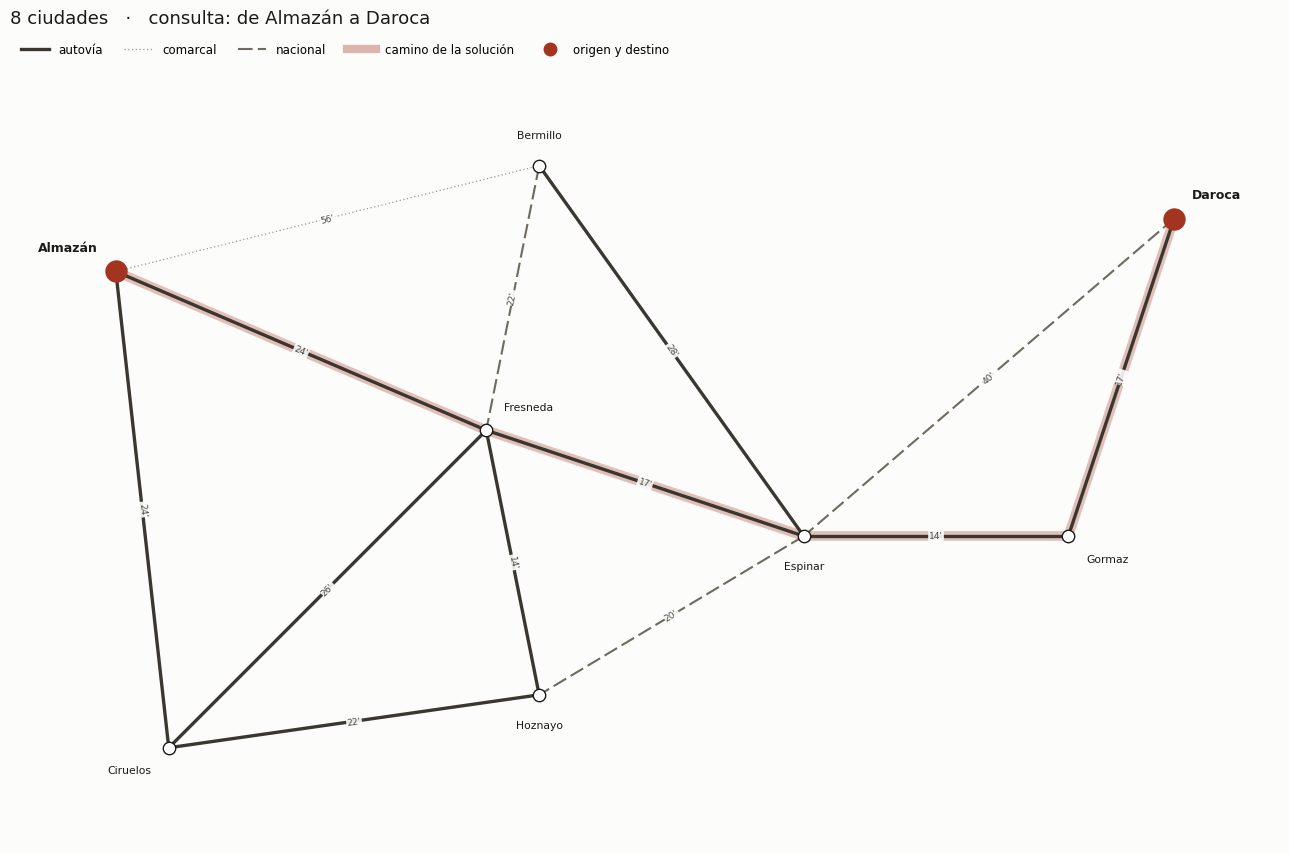

In [30]:
import random
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ESTILO = {'comarcal':       dict(lw=0.9, ls=(0, (1, 2)), color='#9A968A'),
          'nacional':       dict(lw=1.5, ls=(0, (7, 2.5)), color='#6E6A5E'),
          'autovía':        dict(lw=2.4, ls='-', color='#3A3730'),
          'tren lanzadera': dict(lw=2.0, ls=(0, (6, 3)), color='#1F6F8B')}
TINTA, PAPEL, ROJO = '#1A1A1A', '#FCFCFB', '#A3341F'


def _esquema(G, semilla=7, iteraciones=900):
    """Coloca las ciudades usando SOLO la topología. Los km no intervienen."""
    rnd = random.Random(semilla)
    N = sorted(G); n = len(N)
    P = {c: [rnd.uniform(-1, 1), rnd.uniform(-1, 1)] for c in N}
    k = math.sqrt(1.0 / n)
    for paso in range(iteraciones):
        t = 0.12 * (1 - paso / iteraciones) ** 1.5 + 1e-4
        F = {c: [0.0, 0.0] for c in N}
        for i, u in enumerate(N):
            for v in N[i + 1:]:
                dx, dy = P[u][0] - P[v][0], P[u][1] - P[v][1]
                f = 1.6 * k * k / (dx * dx + dy * dy + 1e-9)
                F[u][0] += dx * f; F[u][1] += dy * f
                F[v][0] -= dx * f; F[v][1] -= dy * f
        for u in N:
            for v in G[u]:
                dx, dy = P[u][0] - P[v][0], P[u][1] - P[v][1]
                F[u][0] -= dx / k * 0.5; F[u][1] -= dy / k * 0.5
        for u in N:
            dx, dy = F[u]; d = math.hypot(dx, dy) + 1e-9
            P[u][0] += dx / d * min(d, t); P[u][1] += dy / d * min(d, t)

    def normaliza():                           # a un cuadrado 0..1, conservando la forma
        xs = [p[0] for p in P.values()]; ys = [p[1] for p in P.values()]
        e = max(max(xs) - min(xs), max(ys) - min(ys)) + 1e-9
        for c, p in P.items():
            P[c] = [(p[0] - min(xs)) / e, (p[1] - min(ys)) / e]
    normaliza()

    for _ in range(220):                       # que nadie quede encima de nadie
        movido = False
        for i, u in enumerate(N):
            for v in N[i + 1:]:
                dx, dy = P[u][0] - P[v][0], P[u][1] - P[v][1]
                d = math.hypot(dx, dy)
                if d < 0.085:
                    if d < 1e-6: dx, dy, d = rnd.uniform(-1, 1), rnd.uniform(-1, 1), 1.0
                    e = (0.085 - d) / 2 / d
                    P[u][0] += dx * e; P[u][1] += dy * e
                    P[v][0] -= dx * e; P[v][1] -= dy * e
                    movido = True
        if not movido: break
    normaliza()
    return P


def dibujar(G, KM, VIA, origen=None, destino=None, camino=None,
            etiquetas='minutos', pos=None):
    P = {c: list(p) for c, p in pos.items()} if pos else _esquema(G)
    xs = [p[0] for p in P.values()]; ys = [p[1] for p in P.values()]
    ex, ey = max(xs) - min(xs) + 1e-9, max(ys) - min(ys) + 1e-9
    P = {c: ((p[0] - min(xs)) / max(ex, ey), (p[1] - min(ys)) / max(ex, ey)) for c, p in P.items()}
    enCamino = {tuple(sorted(p)) for p in zip(camino, camino[1:])} if camino else set()

    fig, ax = plt.subplots(figsize=(13, 9))
    fig.patch.set_facecolor(PAPEL); ax.set_facecolor(PAPEL)
    for a in G:
        for b in G[a]:
            if a >= b: continue
            (x1, y1), (x2, y2) = P[a], P[b]
            if tuple(sorted((a, b))) in enCamino:
                ax.plot([x1, x2], [y1, y2], color=ROJO, lw=7, alpha=0.30,
                        solid_capstyle='round', zorder=1)
            ax.plot([x1, x2], [y1, y2], zorder=2, **ESTILO.get(VIA[a][b], ESTILO['nacional']))
            if etiquetas:
                val = G[a][b] if etiquetas == 'minutos' else KM[a][b]
                uni = "'" if etiquetas == 'minutos' else ' km'
                ang = math.degrees(math.atan2(y2 - y1, x2 - x1))
                ang = ang - 180 if ang > 90 else (ang + 180 if ang < -90 else ang)
                ax.text((x1 + x2) / 2, (y1 + y2) / 2, f'{val}{uni}', rotation=ang,
                        rotation_mode='anchor', fontsize=6.5, ha='center', va='center',
                        color='#4A4A42', zorder=3,
                        bbox=dict(boxstyle='round,pad=0.10', fc=PAPEL, ec='none', alpha=0.9))

    ANCLAS = [(1, 0, 'left', 'center'), (.7, .7, 'left', 'bottom'), (0, 1, 'center', 'bottom'),
              (-.7, .7, 'right', 'bottom'), (-1, 0, 'right', 'center'),
              (-.7, -.7, 'right', 'top'), (0, -1, 'center', 'top'), (.7, -.7, 'left', 'top')]
    for c, (x, y) in P.items():
        od = c in (origen, destino)
        ax.scatter([x], [y], s=210 if od else 80, c=ROJO if od else 'white',
                   edgecolors=ROJO if od else TINTA, linewidths=1.6 if od else 1.0, zorder=4)
        vx = sum(P[v][0] - x for v in G[c]) / len(G[c])
        vy = sum(P[v][1] - y for v in G[c]) / len(G[c])
        mejor_a, top = ANCLAS[6], -1e9
        for dx, dy, ha, va in ANCLAS:
            p = -(dx * vx + dy * vy) * 3
            p += min(math.hypot(x + dx * .05 - P[o][0], y + dy * .05 - P[o][1])
                     for o in P if o != c)
            if p > top: mejor_a, top = (dx, dy, ha, va), p
        dx, dy, ha, va = mejor_a
        ax.text(x + dx * .024, y + dy * .024, c, fontsize=9 if od else 7.8,
                fontweight='bold' if od else 'normal', ha=ha, va=va, color=TINTA, zorder=5,
                bbox=dict(boxstyle='round,pad=0.14', fc=PAPEL, ec='none', alpha=0.88))

    vias = sorted({VIA[a][b] for a in G for b in G[a]})
    leg = [Line2D([], [], **ESTILO[t], label=t) for t in vias if t in ESTILO]
    if camino: leg.append(Line2D([], [], color=ROJO, lw=6, alpha=.35, label='camino de la solución'))
    if origen: leg.append(Line2D([], [], marker='o', ls='', mfc=ROJO, mec=ROJO, ms=9,
                                 label='origen y destino'))
    ax.legend(handles=leg, loc='lower left', bbox_to_anchor=(0, 1.005), ncol=len(leg),
              frameon=False, fontsize=8.5, columnspacing=1.8, handlelength=2.4)
    t = f'{len(G)} ciudades'
    if origen and destino: t += f'   ·   consulta: de {origen} a {destino}'
    ax.set_title(t, fontsize=13, color=TINTA, loc='left', pad=34)
    if pos is None:
        ax.text(0, -.055, 'Esquema: las ciudades se colocan solo con las conexiones. '
                          'Las distancias del dibujo NO son las del mapa.',
                transform=ax.transAxes, fontsize=8, color='#7A1F1F', style='italic')
    xs = [p[0] for p in P.values()]; ys = [p[1] for p in P.values()]
    mx, my = 0.10, 0.09
    ax.set_xlim(min(xs) - mx, max(xs) + mx)
    ax.set_ylim(min(ys) - my, max(ys) + my)
    ax.set_aspect('equal'); ax.axis('off')
    fig.tight_layout(); plt.show()


# el ejemplo, a escala (tiene coordenadas)
dibujar(Ge, KMe, VIAe, ORIGEN_E, DESTINO_E,
        camino=buscar(Ge, ORIGEN_E, DESTINO_E, h_buena)['camino'], pos=COORD)

Y el vuestro. Si ya habéis ejecutado la celda II.4, poned `camino=r1['camino']`
para que resalte vuestra solución.

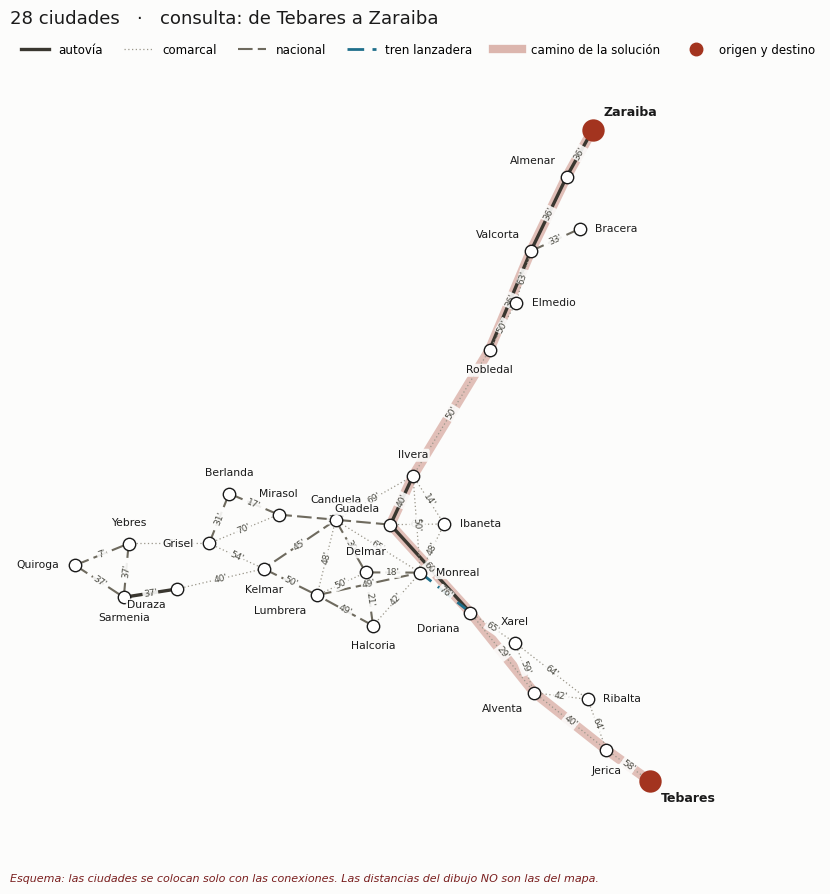

In [31]:
dibujar(G, KM, VIA, ORIGEN or None, DESTINO or None,
        camino=r1['camino'] if r1 else None)

---
## Qué hay que entregar

1. Este cuaderno con vuestra heurística escrita (o el `.py` equivalente).
2. La tabla de la Fase 3, rellena.
3. Las respuestas de la Fase 4, máximo una página.
4. **Media página justificando por qué vuestra heurística nunca sobreestima.**
   No vale «lo hemos comprobado con el programa»: se pide el argumento.

Un solo fichero `apellido1_apellido2_lab2.zip`, hasta el lunes 5 de octubre a las 23:59.